<a href="https://colab.research.google.com/github/mahihshah/plural-discounting/blob/main/CIVI_for_Plural_Discounting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# A Brief Introduction to CIVI and Plural Discounting

Long-run climate policy requires translating future climate damages and benefits into present values. This necessarily involves discounting, which determines how strongly we weight the welfare of future generations relative to the present. Small changes in discounting assumptions can generate very large differences in the estimated value of mitigation, adaptation, and carbon storage policies.


However, there is persistent disagreement over the key determinants of the social discount rate: the pure rate of time preference, the elasticity of marginal utility of consumption, long-run growth expectations, and the treatment of risk, including low-probability catastrophic outcomes. These disagreements are not merely empirical; they reflect deeper normative commitments about intergenerational equity and social welfare.


Under normative uncertainty, no single discount function can be assumed to represent the “correct” ethical stance. Instead, multiple ethically defensible discount functions may coexist.


The Composite Intertemporal Valuation Instrument (CIVI) treats discounting as an object of aggregation: CIVI is defined as a weighted combination of discount functions corresponding to distinct ethical positions, where weights represent credences over competing moral theories.

# Discounting Equations

Because there is no single uncontested theory of intertemporal social welfare, this analysis employs a range of discounting formulations. These formulations differ in their treatment of time preference, inequality aversion, growth, uncertainty, and catastrophic risk. Some arise from welfare economics, others from asset pricing, behavioural models, or public policy practice.

Rather than presuming one structure to be normatively correct, CIVI treats these alternative discount factors as ethically admissible candidates. Their formal expressions are provided below.

Ramsey Rule
\begin{equation}
r = \delta + \eta g
\end{equation}

Exponential Discount Factor
\begin{equation}
D(t) = e^{-rt}
\end{equation}

Discrete Exponential Present Value
\begin{equation}
PV = \frac{FV}{(1 + r)^t}
\end{equation}

Continuous-Time Present Value
\begin{equation}
PV = \int_0^T e^{-rt} X(t)\, dt
\end{equation}

Intergenerational Discounting
\begin{equation}
r = \rho + (1 - \alpha)\eta g
\end{equation}

Consumption-Based Discounting
\begin{equation}
r = \rho + \gamma g_c
\end{equation}

CRRA Utility
\begin{equation}
U(c) = \frac{c^{1-\eta} - 1}{1-\eta}
\end{equation}

CARA Utility
\begin{equation}
U(c) = -\frac{e^{-ac}}{a}
\end{equation}

Certainty-Equivalent Adjustment
\begin{equation}
CE = E[X] - \lambda \, \mathrm{Var}(X)
\end{equation}

Declining Discount Rate (DDR)
\begin{equation}
r_t = r_0 e^{-\alpha t}
\end{equation}

Term Structure Discounting
\begin{equation}
PV = \sum_{t=0}^{T} \frac{CF_t}{(1 + r_t)^t}
\end{equation}

Dual-Rate Discounting
\begin{equation}
PV = \sum_{t=0}^{T_s} \frac{B_t}{(1 + r_s)^t}
+ \sum_{t=T_s}^{T} \frac{B_t}{(1 + r_l)^t}
\end{equation}

Gamma Discounting (Rate Uncertainty)
\begin{equation}
E[D(t)] = \int_0^{\infty} e^{-rt} f(r)\, dr
\end{equation}

Stochastic Discount Factor
\begin{equation}
D(t) = E\left[ e^{-\int_0^t r_s ds} \right]
\end{equation}

Risk-Adjusted Discounting (CAPM)
\begin{equation}
r_{adj} = r_f + \beta (r_m - r_f)
\end{equation}

Precautionary Growth Adjustment
\begin{equation}
r = \delta + \eta g - \frac{1}{2}\eta(\eta+1)\sigma_g^2
\end{equation}

Catastrophic Jump Risk
\begin{equation}
r = \delta + \eta g + pL
\end{equation}

Weighted Average Cost of Capital (WACC)
\begin{equation}
r = \sum_{i} w_i r_i
\end{equation}

Hyperbolic Discounting
\begin{equation}
PV = \frac{FV}{1 + k t}
\end{equation}

Generalised Hyperbolic
\begin{equation}
D(t) = (1 + k t)^{-\alpha}
\end{equation}

Quasi-Hyperbolic Discounting
\begin{equation}
PV = \beta \frac{FV}{(1 + r)^t}
\end{equation}

Green Discounting
\begin{equation}
r_{\text{green}} = r - \alpha
\end{equation}


In [1]:
# ================================
# GLOBAL IMPORTS AND ENVIRONMENT
# ================================

import numpy as np
import pandas as pd
import scipy
from scipy import stats
from scipy.stats import (
    norm, lognorm, uniform, beta, gamma, truncnorm, expon, weibull_min
)
from scipy.optimize import minimize, root, fsolve
from scipy.integrate import quad, simpson
from scipy.interpolate import interp1d
from scipy.linalg import eigvals
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from numpy.random import default_rng
rng = default_rng(42)
from numpy import gradient
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
plt.style.use("seaborn-v0_8")
sns.set_context("talk")
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings("ignore")

# ================================
# TIME HORIZON SETUP
# ================================

T   = 300
dt  = 1
t   = np.arange(0, T + dt, dt)   # shape (301,)

# ================================
# DISPLAY SETTINGS
# ================================

pd.set_option("display.float_format", "{:.6f}".format)
pd.set_option("display.max_columns", 50)

print("Environment successfully initialised.")
print(f"Time horizon: {T} years | Periods: {len(t)}")

Environment successfully initialised.
Time horizon: 300 years | Periods: 301


In [2]:
# ============================================================
# DISCOUNT FUNCTION LIBRARY  —  22 methods
# Each function returns a numpy array D of shape (301,)
# with D[0] = 1 (present = full value) and D[t] ∈ (0,1].
# ============================================================

# ----------------------------------------------------------
# 1. RAMSEY RULE — Pure Exponential
#    r  = δ + η·g
#    D(t) = e^{−r·t}
# ----------------------------------------------------------
def d01_ramsey_exponential(t, delta=0.015, eta=1.5, g=0.02):
    r = delta + eta * g
    return np.exp(-r * t)


# ----------------------------------------------------------
# 2. DISCRETE EXPONENTIAL
#    D(t) = 1 / (1 + r)^t
#    Discrete-time analogue of the exponential factor.
# ----------------------------------------------------------
def d02_discrete_exponential(t, delta=0.015, eta=1.5, g=0.02):
    r = delta + eta * g
    return 1.0 / (1.0 + r) ** t


# ----------------------------------------------------------
# 3. CONTINUOUS-TIME DISCOUNT FACTOR
#    Integrand of: PV = ∫₀ᵀ e^{−r·t} X(t) dt
#    Here we return the discount kernel e^{−r·t}
#    (identical in form to D01 but separated for clarity
#     as the continuous-time present value operator).
# ----------------------------------------------------------
def d03_continuous_time(t, delta=0.015, eta=1.5, g=0.02):
    r = delta + eta * g
    return np.exp(-r * t)


# ----------------------------------------------------------
# 4. INTERGENERATIONAL DISCOUNTING
#    r  = ρ + (1 − α)·η·g
#    α ∈ [0,1] governs intergenerational altruism:
#    α = 0 → standard Ramsey; α = 1 → ρ only (pure patience)
# ----------------------------------------------------------
def d04_intergenerational(t, rho=0.015, alpha=0.5, eta=1.5, g=0.02):
    r = rho + (1.0 - alpha) * eta * g
    return np.exp(-r * t)


# ----------------------------------------------------------
# 5. CONSUMPTION-BASED DISCOUNTING
#    r  = ρ + γ·g_c
#    γ is the coefficient of relative risk aversion;
#    g_c is the consumption growth rate (may differ from g).
# ----------------------------------------------------------
def d05_consumption_based(t, rho=0.015, gamma_rra=1.5, g_c=0.02):
    r = rho + gamma_rra * g_c
    return np.exp(-r * t)


# ----------------------------------------------------------
# 6. CRRA UTILITY-BASED DISCOUNT FACTOR
#    U(c) = (c^{1−η} − 1) / (1 − η)    [η ≠ 1]
#    Marginal utility: U′(c) = c^{−η}
#    Stochastic Euler condition implies:
#    D(t) = e^{−δ·t} · (C_t / C_0)^{−η}
#         = e^{−δ·t} · e^{−η·g·t}
#         = e^{−(δ + η·g)·t}
#    Distinguishes δ (pure patience) from η (curvature) explicitly.
# ----------------------------------------------------------
def d06_crra(t, delta=0.015, eta=1.5, g=0.02):
    # C_t / C_0 = e^{g·t}  →  (C_t/C_0)^{−η} = e^{−η·g·t}
    return np.exp(-delta * t) * np.exp(-eta * g * t)


# ----------------------------------------------------------
# 7. CARA UTILITY-BASED DISCOUNT FACTOR
#    U(c) = −e^{−a·c} / a
#    Marginal utility: U′(c) = e^{−a·c}
#    D(t) = e^{−δ·t} · e^{−a·(C_t − C_0)}
#         = e^{−δ·t} · e^{−a·C_0·(e^{g·t} − 1)}
#    Absolute risk aversion is constant (= a), independent of wealth.
# ----------------------------------------------------------
def d07_cara(t, delta=0.015, a=0.5, C0=1.0, g=0.02):
    consumption_gain = C0 * (np.exp(g * t) - 1.0)
    return np.exp(-delta * t) * np.exp(-a * consumption_gain)


# ----------------------------------------------------------
# 8. CERTAINTY-EQUIVALENT ADJUSTMENT
#    CE  = E[X] − λ·Var(X)
#    Effective discount rate incorporates a risk penalty λ
#    on the variance of the future benefit stream.
#    D(t) = e^{−(r + λ·σ²)·t}
#    where σ² is the per-period variance of X(t).
# ----------------------------------------------------------
def d08_certainty_equivalent(t, delta=0.015, eta=1.5, g=0.02,
                              lam=0.5, sigma2=0.01):
    r_base = delta + eta * g
    r_adj  = r_base + lam * sigma2
    return np.exp(-r_adj * t)


# ----------------------------------------------------------
# 9. DECLINING DISCOUNT RATE (DDR)
#    r(t) = r₀ · e^{−α·t}
#    Discount factor: D(t) = exp(−∫₀ᵗ r(s) ds)
#                           = exp(−r₀/α · (1 − e^{−α·t}))
# ----------------------------------------------------------
def d09_declining_discount_rate(t, r0=0.04, alpha_ddr=0.02):
    integral = (r0 / alpha_ddr) * (1.0 - np.exp(-alpha_ddr * t))
    return np.exp(-integral)


# ----------------------------------------------------------
# 10. TERM STRUCTURE DISCOUNTING
#     PV = Σ CF_t / (1 + r_t)^t
#     r_t is a time-varying term structure; here modelled as:
#     r_t = r_short  for t ≤ T_mid
#     r_t = r_long   for t >  T_mid   (simplified schedule)
#     Returns the discount factor 1/(1+r_t)^t for each t.
# ----------------------------------------------------------
def d10_term_structure(t, r_short=0.035, r_long=0.025, T_mid=30):
    # Discount factor must be continuous across the threshold.
    # For t <= T_mid: D(t) = 1/(1+r_short)^t
    # For t >  T_mid: D(t) = D(T_mid) * 1/(1+r_long)^{t - T_mid}
    # This prevents the upward jump that occurs when r_long < r_short.
    D_mid = 1.0 / (1.0 + r_short) ** T_mid
    D = np.where(
        t <= T_mid,
        1.0 / (1.0 + r_short) ** t,
        D_mid * (1.0 / (1.0 + r_long) ** (t - T_mid))
    )
    D[0] = 1.0
    return D

# ----------------------------------------------------------
# 11. DUAL-RATE DISCOUNTING
#     PV = Σ_{t=0}^{T_s} B_t/(1+r_s)^t  +  Σ_{t=T_s}^{T} B_t/(1+r_l)^t
#     Returns the discount factor applicable at each t:
#     D(t) = 1/(1+r_s)^t          for t ≤ T_s
#     D(t) = 1/(1+r_s)^T_s · 1/(1+r_l)^{t−T_s}   for t > T_s
#     (discount is continuous across the threshold)
# ----------------------------------------------------------
def d11_dual_rate(t, r_short=0.035, r_long=0.010, T_s=30):
    D = np.where(
        t <= T_s,
        1.0 / (1.0 + r_short) ** t,
        (1.0 / (1.0 + r_short) ** T_s) *
        (1.0 / (1.0 + r_long)  ** (t - T_s))
    )
    D[0] = 1.0
    return D


# ----------------------------------------------------------
# 12. GAMMA DISCOUNTING — Rate Uncertainty (Weitzman)
#     E[D(t)] = ∫₀^∞ e^{−r·t} f(r) dr
#     If r ~ Gamma(α_shape, β_scale), the MGF gives:
#     E[D(t)] = (1 + β_scale · t)^{−α_shape}
# ----------------------------------------------------------
def d12_gamma_discounting(t, alpha_shape=2.0, beta_scale=0.02):
    return (1.0 + beta_scale * t) ** (-alpha_shape)


# ----------------------------------------------------------
# 13. STOCHASTIC DISCOUNT FACTOR
#     D(t) = E[e^{−∫₀ᵗ r_s ds}]
#     r_s follows an Ornstein-Uhlenbeck (mean-reverting) process:
#     dr_s = κ(θ − r_s)ds + σ dW_s
#     Analytical solution (Vasicek):
#     E[D(t)] = exp(A(t) − B(t)·r₀)
#     B(t) = (1 − e^{−κt}) / κ
#     A(t) = (θ − σ²/(2κ²))·(B(t) − t) − σ²·B(t)²/(4κ)
# ----------------------------------------------------------
def d13_stochastic_discount_factor(t, kappa=0.1, theta=0.03,
                                    sigma_r=0.01, r0=0.03):
    B = (1.0 - np.exp(-kappa * t)) / kappa
    A = ((theta - sigma_r**2 / (2.0 * kappa**2)) * (B - t)
         - sigma_r**2 * B**2 / (4.0 * kappa))
    D = np.exp(A - B * r0)
    D[0] = 1.0
    return D


# ----------------------------------------------------------
# 14. RISK-ADJUSTED DISCOUNTING — CAPM
#     r_adj = r_f + β·(r_m − r_f)
#     D(t)  = e^{−r_adj · t}
# ----------------------------------------------------------
def d14_capm(t, r_f=0.01, beta_capm=0.5, r_m=0.07):
    r_adj = r_f + beta_capm * (r_m - r_f)
    return np.exp(-r_adj * t)


# ----------------------------------------------------------
# 15. PRECAUTIONARY GROWTH ADJUSTMENT
#     r = δ + η·g − ½·η·(η+1)·σ_g²
#     The third term is the precautionary effect: higher growth
#     variance lowers the effective discount rate.
# ----------------------------------------------------------
def d15_precautionary(t, delta=0.015, eta=1.5, g=0.02, sigma_g=0.01):
    r = delta + eta * g - 0.5 * eta * (eta + 1.0) * sigma_g**2
    return np.exp(-r * t)


# ----------------------------------------------------------
# 16. CATASTROPHIC JUMP RISK
#     r = δ + η·g + p·L
#     p = annual probability of catastrophe
#     L = fractional welfare loss on impact
# ----------------------------------------------------------
def d16_catastrophic_jump(t, delta=0.015, eta=1.5, g=0.02,
                           p=0.01, L=0.30):
    r = delta + eta * g + p * L
    return np.exp(-r * t)


# ----------------------------------------------------------
# 17. WEIGHTED AVERAGE COST OF CAPITAL (WACC)
#     r = Σ wᵢ·rᵢ
#     Here parameterised with equity and debt components:
#     r = w_e·r_e + w_d·r_d·(1 − tax)
# ----------------------------------------------------------
def d17_wacc(t, w_equity=0.6, r_equity=0.08,
              w_debt=0.4, r_debt=0.04, tax_rate=0.25):
    r = w_equity * r_equity + w_debt * r_debt * (1.0 - tax_rate)
    return np.exp(-r * t)


# ----------------------------------------------------------
# 18. HYPERBOLIC DISCOUNTING
#     D(t) = 1 / (1 + k·t)
# ----------------------------------------------------------
def d18_hyperbolic(t, k=0.03):
    return 1.0 / (1.0 + k * t)


# ----------------------------------------------------------
# 19. GENERALISED HYPERBOLIC
#     D(t) = (1 + k·t)^{−α}
#     α = 1 recovers standard hyperbolic (D18).
# ----------------------------------------------------------
def d19_generalised_hyperbolic(t, k=0.03, alpha_hyp=1.5):
    return (1.0 + k * t) ** (-alpha_hyp)


# ----------------------------------------------------------
# 20. QUASI-HYPERBOLIC DISCOUNTING
#     D(t) = 1              for t = 0
#     D(t) = β·(1+r)^{−t}  for t > 0
#     β ∈ (0,1) is the present-bias parameter.
# ----------------------------------------------------------
def d20_quasi_hyperbolic(t, beta_qh=0.7, delta=0.015, eta=1.5, g=0.02):
    r  = delta + eta * g
    D  = beta_qh / (1.0 + r) ** t
    D[0] = 1.0    # normalise: no discounting at t=0
    return D


# ----------------------------------------------------------
# 21. GREEN DISCOUNTING
#     r_green = r − α_green
#     α_green is the environmental dividend / negative externality
#     correction term, reflecting that environmental goods
#     appreciate relative to consumption goods over time.
# ----------------------------------------------------------
def d21_green_discounting(t, delta=0.015, eta=1.5, g=0.02,
                           alpha_green=0.01):
    r       = delta + eta * g
    r_green = max(r - alpha_green, 0.0)   # floor at zero
    return np.exp(-r_green * t)


# ----------------------------------------------------------
# 22. NEAR-ZERO TIME PREFERENCE (Stern-style)
#     δ ≈ 0 (set to 0.001): only η·g drives discounting.
#     Represents the ethical position that future persons
#     deserve near-equal weight to present persons.
# ----------------------------------------------------------
def d22_near_zero_time_preference(t, delta=0.001, eta=1.5, g=0.02):
    r = delta + eta * g
    return np.exp(-r * t)


# ============================================================
# COLLECT ALL 22 FUNCTIONS INTO ORDERED LIST
# ============================================================

discount_functions = [
    d01_ramsey_exponential,
    d02_discrete_exponential,
    d03_continuous_time,
    d04_intergenerational,
    d05_consumption_based,
    d06_crra,
    d07_cara,
    d08_certainty_equivalent,
    d09_declining_discount_rate,
    d10_term_structure,
    d11_dual_rate,
    d12_gamma_discounting,
    d13_stochastic_discount_factor,
    d14_capm,
    d15_precautionary,
    d16_catastrophic_jump,
    d17_wacc,
    d18_hyperbolic,
    d19_generalised_hyperbolic,
    d20_quasi_hyperbolic,
    d21_green_discounting,
    d22_near_zero_time_preference,
]

labels = [
    "D01 Ramsey Exponential",
    "D02 Discrete Exponential",
    "D03 Continuous-Time",
    "D04 Intergenerational",
    "D05 Consumption-Based",
    "D06 CRRA Utility",
    "D07 CARA Utility",
    "D08 Certainty-Equivalent",
    "D09 Declining Discount Rate",
    "D10 Term Structure",
    "D11 Dual-Rate",
    "D12 Gamma (Weitzman)",
    "D13 Stochastic (Vasicek)",
    "D14 CAPM Risk-Adjusted",
    "D15 Precautionary",
    "D16 Catastrophic Jump",
    "D17 WACC",
    "D18 Hyperbolic",
    "D19 Generalised Hyperbolic",
    "D20 Quasi-Hyperbolic",
    "D21 Green Discounting",
    "D22 Near-Zero Time Preference",
]

# ============================================================
# COMPUTE D_array: shape (22, 301)
# ============================================================

D_array = np.array([fn(t) for fn in discount_functions])

# ============================================================
# VALIDATION CHECKS
# ============================================================

print("\n=== Discount Function Validation ===")
print(f"{'#':<5} {'Label':<35} {'D(0)':<10} {'Monotone':<10} {'Min>0'}")
print("-" * 70)

all_passed = True
for i, (label, D) in enumerate(zip(labels, D_array)):
    d0_ok      = np.isclose(D[0], 1.0, atol=1e-6)
    monotone   = np.all(np.diff(D) <= 1e-9)
    positive   = np.all(D > 0)
    status     = "PASS" if (d0_ok and monotone and positive) else "FAIL"
    if status == "FAIL":
        all_passed = False
    print(f"{i+1:<5} {label:<35} {D[0]:<10.6f} {str(monotone):<10} {positive}  [{status}]")

print("-" * 70)
print("All checks passed." if all_passed else "One or more checks failed - review flagged functions.")


=== Discount Function Validation ===
#     Label                               D(0)       Monotone   Min>0
----------------------------------------------------------------------
1     D01 Ramsey Exponential              1.000000   True       True  [PASS]
2     D02 Discrete Exponential            1.000000   True       True  [PASS]
3     D03 Continuous-Time                 1.000000   True       True  [PASS]
4     D04 Intergenerational               1.000000   True       True  [PASS]
5     D05 Consumption-Based               1.000000   True       True  [PASS]
6     D06 CRRA Utility                    1.000000   True       True  [PASS]
7     D07 CARA Utility                    1.000000   True       True  [PASS]
8     D08 Certainty-Equivalent            1.000000   True       True  [PASS]
9     D09 Declining Discount Rate         1.000000   True       True  [PASS]
10    D10 Term Structure                  1.000000   True       True  [PASS]
11    D11 Dual-Rate                       1.000000 

# Baseline Parameters & CIVI Aggregation

This section establishes the normative and empirical inputs to the CIVI operator.

Parameter uncertainty reflects ignorance about the world; weight uncertainty reflects genuine disagreement about which ethical theory correctly characterises intergenerational obligations.

$$CIVI(t) = \sum_{i=1}^{22} w_i D_i(t), \qquad \sum_{i=1}^{22} w_i = 1, \quad w_i \geq 0$$



In [3]:

# ── Ramsey welfare parameters ──────────────────────────────────
delta_base   = 0.015   # Pure rate of time preference     [0, 0.03]
eta_base     = 1.5     # Elasticity of marginal utility   [0.5, 4.0]
g_base       = 0.020   # Consumption growth rate          [0, 0.03]
sigma_g      = 0.010   # Growth volatility (std dev)

# ── Hyperbolic / generalised hyperbolic ───────────────────────
k_hyperbolic    = 0.030   # Hyperbolic decay parameter
alpha_genhyp    = 1.500   # Generalised hyperbolic exponent

# ── Risk and uncertainty parameters ───────────────────────────
p_catastrophe   = 0.010   # Annual probability of catastrophic jump
L_loss          = 0.300   # Fractional welfare loss on catastrophe
xi_ambiguity    = 0.005   # Ambiguity (Ellsberg) premium

# ── CAPM / asset pricing parameters ───────────────────────────
beta_capm       = 0.500   # Market beta
lambda_risk     = 0.040   # Market risk premium
r_f             = 0.010   # Risk-free rate

# ── Weitzman gamma-discounting parameters ──────────────────────
mu_r            = delta_base + eta_base * g_base   # Mean of rate distribution
sigma_r         = 0.010                            # Std dev of rate distribution

# ── Sufficientarian threshold (normalised welfare index) ───────
W_star          = 0.500   # Welfare threshold as fraction of current level

# ── Stochastic process parameters (Ornstein-Uhlenbeck) ─────────
theta_ou        = 0.100   # Mean-reversion speed
sigma_ou        = 0.010   # OU process volatility

# ── Prioritarian parameters ────────────────────────────────────
gamma_prioritarian = 0.500  # Concavity of welfare weighting function

# ─────────────────────────────────────────────────────────────
# Display all parameters in a clean table
# ─────────────────────────────────────────────────────────────

param_dict = {
    "Parameter": [
        "δ (delta_base)",    "η (eta_base)",      "g (g_base)",
        "σ_g (sigma_g)",     "k (k_hyperbolic)",  "α (alpha_genhyp)",
        "p_cat",             "L_loss",            "ξ (xi_ambiguity)",
        "β_CAPM",            "λ_risk",            "r_f",
        "μ_r",               "σ_r",               "W*",
        "θ_OU",              "σ_OU",              "γ_prioritarian"
    ],
    "Value": [
        delta_base, eta_base, g_base,
        sigma_g, k_hyperbolic, alpha_genhyp,
        p_catastrophe, L_loss, xi_ambiguity,
        beta_capm, lambda_risk, r_f,
        mu_r, sigma_r, W_star,
        theta_ou, sigma_ou, gamma_prioritarian
    ],
    "Description": [
        "Pure rate of time preference",
        "Elasticity of marginal utility (CRRA)",
        "Baseline consumption growth rate",
        "Consumption growth volatility",
        "Hyperbolic decay parameter",
        "Generalised hyperbolic exponent",
        "Annual catastrophic jump probability",
        "Welfare loss fraction on catastrophe",
        "Ambiguity / Ellsberg premium",
        "Market beta (CAPM)",
        "Market risk premium",
        "Risk-free rate",
        "Mean of rate distribution (Weitzman)",
        "Std dev of rate (Weitzman gamma-disc.)",
        "Sufficientarian welfare threshold",
        "OU mean-reversion speed",
        "OU process volatility",
        "Prioritarian welfare weight concavity"
    ],
    "Calibration range / note": [
        "[0, 0.03] — Stern(~0) to Nordhaus(0.03)",
        "[0.5, 4.0] — near-linear to strong inequality aversion",
        "[0, 0.03] — stagnation to moderate growth",
        "Symmetric around baseline g",
        "[0.01, 0.05]",
        "Fixed at 1.5 (moderate generalisation)",
        "~0.01 consistent with climate tail literature",
        "30% welfare loss on catastrophe event",
        "[0, 0.01] — small but non-trivial",
        "0.5 — moderate market exposure",
        "4% equity risk premium",
        "1% — consistent with long-run public investment",
        "Derived: δ + η·g",
        "±1pp around mean rate",
        "0.5 = halfway up welfare scale",
        "Slow mean-reversion",
        "Calibrated to growth volatility",
        "[0, 1] — 0.5 is moderate prioritarian weight"
    ]
}

df_params = pd.DataFrame(param_dict)
df_params.index = df_params.index + 1  # 1-indexed for readability

print("=" * 70)
print("  CIVI BASELINE PARAMETER SPECIFICATION")
print("=" * 70)
print(df_params[["Parameter","Value","Description"]].to_string(index=True))
print()
print(f"  Ramsey baseline rate: r = δ + η·g = "
      f"{delta_base} + {eta_base}×{g_base} = "
      f"{delta_base + eta_base * g_base:.4f}")
print("=" * 70)
print("  NOTE: These parameters are used for deterministic baseline only.")
print("  Stochastic draws replace them in Monte Carlo (see section later).")
print("=" * 70)

  CIVI BASELINE PARAMETER SPECIFICATION
           Parameter    Value                             Description
1     δ (delta_base) 0.015000            Pure rate of time preference
2       η (eta_base) 1.500000   Elasticity of marginal utility (CRRA)
3         g (g_base) 0.020000        Baseline consumption growth rate
4      σ_g (sigma_g) 0.010000           Consumption growth volatility
5   k (k_hyperbolic) 0.030000              Hyperbolic decay parameter
6   α (alpha_genhyp) 1.500000         Generalised hyperbolic exponent
7              p_cat 0.010000    Annual catastrophic jump probability
8             L_loss 0.300000    Welfare loss fraction on catastrophe
9   ξ (xi_ambiguity) 0.005000            Ambiguity / Ellsberg premium
10            β_CAPM 0.500000                      Market beta (CAPM)
11            λ_risk 0.040000                     Market risk premium
12               r_f 0.010000                          Risk-free rate
13               μ_r 0.045000    Mean of rate dist

In [4]:
print("Computing baseline discount array D_array [22 × 301]...")
print()

# ── Collect all 22 functions into D_array ─────────────────────
D_array = np.zeros((22, len(t)))

param_kwargs = dict(
    delta       = delta_base,
    eta         = eta_base,
    g           = g_base,
    sigma_g     = sigma_g,
    k           = k_hyperbolic,
    alpha       = alpha_genhyp,
    p           = p_catastrophe,
    L           = L_loss,
    xi          = xi_ambiguity,
    beta_capm   = beta_capm,
    lam         = lambda_risk,
    r_f         = r_f,
    mu_r        = mu_r,
    sigma_r     = sigma_r,
    W_star      = W_star,
    theta_ou    = theta_ou,
    sigma_ou    = sigma_ou,
    gamma_p     = gamma_prioritarian,
)

for i, func in enumerate(discount_functions):
    try:
        result = func(t, **param_kwargs)
        D_array[i] = result
    except Exception as e:
        print(f"  ⚠  D{i+1} failed: {e}")
        D_array[i] = np.ones(len(t))  # fallback — flat line, flagged

# ── Validation checks ─────────────────────────────────────────
print(f"  {'#':<4} {'Name':<35} {'D(0)':>8} {'Normalised':>12} "
      f"{'Monotone':>10} {'All > 0':>10}")
print("  " + "─" * 83)

function_labels = [
    "D1  Pure Exponential",         "D2  Near-Zero (Stern-style)",
    "D3  Hyperbolic",               "D4  Generalised Hyperbolic",
    "D5  Weitzman Gamma-Disc.",      "D6  Declining Certainty-Equiv.",
    "D7  Epstein-Zin",              "D8  CAPM Risk-Adjusted",
    "D9  Catastrophic Jump Risk",   "D10 Ambiguity-Adjusted",
    "D11 Dual-Rate (UK Green Book)","D12 State-Dependent",
    "D13 Log-Utility (η=1)",        "D14 CRRA General",
    "D15 Stochastic Growth (OU)",   "D16 Consumption-Based AP",
    "D17 Fat-Tailed Damage Risk",   "D18 Precautionary Savings",
    "D19 Prioritarian",             "D20 Sufficientarian Threshold",
    "D21 Maximin-Consistent",       "D22 Longtermist / IGE Altruism",
]

all_pass = True
for i in range(22):
    d0       = D_array[i, 0]
    norm_ok  = np.isclose(d0, 1.0, atol=1e-6)
    mono_ok  = np.all(np.diff(D_array[i]) <= 1e-10)
    pos_ok   = np.all(D_array[i] > 0)

    norm_str = "✓ PASS" if norm_ok else "✗ FAIL"
    mono_str = "✓ PASS" if mono_ok else "✗ FAIL"
    pos_str  = "✓ PASS" if pos_ok  else "✗ FAIL"

    if not (norm_ok and mono_ok and pos_ok):
        all_pass = False

    print(f"  {i+1:<4} {function_labels[i]:<35} {d0:>8.6f} "
          f"{norm_str:>12} {mono_str:>10} {pos_str:>10}")

print("  " + "─" * 83)
status = "All 22 functions passed validation." if all_pass \
    else "One or more functions failed — review above before proceeding."
print(f"\n  {status}")
print(f"\n  D_array shape: {D_array.shape}  (22 functions × 301 time steps)")

Computing baseline discount array D_array [22 × 301]...

  ⚠  D1 failed: d01_ramsey_exponential() got an unexpected keyword argument 'sigma_g'
  ⚠  D2 failed: d02_discrete_exponential() got an unexpected keyword argument 'sigma_g'
  ⚠  D3 failed: d03_continuous_time() got an unexpected keyword argument 'sigma_g'
  ⚠  D4 failed: d04_intergenerational() got an unexpected keyword argument 'delta'
  ⚠  D5 failed: d05_consumption_based() got an unexpected keyword argument 'delta'
  ⚠  D6 failed: d06_crra() got an unexpected keyword argument 'sigma_g'
  ⚠  D7 failed: d07_cara() got an unexpected keyword argument 'eta'
  ⚠  D8 failed: d08_certainty_equivalent() got an unexpected keyword argument 'sigma_g'
  ⚠  D9 failed: d09_declining_discount_rate() got an unexpected keyword argument 'delta'
  ⚠  D10 failed: d10_term_structure() got an unexpected keyword argument 'delta'
  ⚠  D11 failed: d11_dual_rate() got an unexpected keyword argument 'delta'
  ⚠  D12 failed: d12_gamma_discounting() got a

In [5]:
#Interactive Moral Weight Specification
# Purpose : Allow the analyst to declare w = [w₁,...,w₂₂] before CIVI is computed.
#           Three modes: Uniform / Theory-informed / Custom.
#
# DESIGN RATIONALE:
#   Weights are credences over ethical theories — they must be
#   declared as a pre-analytical normative commitment, not
#   derived from model outputs. The UI enforces this by making
#   declaration explicit, auditable, and constraint-checked.
# ─────────────────────────────────────────────────────────────

import ipywidgets as widgets
from IPython.display import display, clear_output

# ── Preset weight vectors ──────────────────────────────────────

PRESETS = {

    "Uniform (neutrality baseline)": np.ones(22) / 22,

    "Theory-informed: Precautionary emphasis": np.array([
        # D1  D2    D3    D4    D5    D6    D7    D8    D9    D10
        0.04, 0.04, 0.02, 0.02, 0.06, 0.06, 0.03, 0.02, 0.07, 0.06,
        # D11  D12   D13   D14   D15   D16   D17   D18   D19   D20
        0.04, 0.05,  0.03, 0.03, 0.05, 0.04, 0.06, 0.08, 0.07, 0.04,
        # D21  D22
        0.04, 0.05
    ]),

    "Theory-informed: Longtermist emphasis": np.array([
        0.02, 0.05, 0.03, 0.03, 0.04, 0.04, 0.04, 0.01, 0.04, 0.03,
        0.02, 0.03, 0.02, 0.02, 0.05, 0.05, 0.05, 0.05, 0.08, 0.05,
        0.08, 0.12
    ]),

    "Scenario: Climate / CDR policy": np.array([
        0.03, 0.05, 0.02, 0.02, 0.06, 0.06, 0.04, 0.02, 0.09, 0.07,
        0.03, 0.05, 0.02, 0.02, 0.05, 0.04, 0.07, 0.07, 0.06, 0.04,
        0.05, 0.05
    ]),

    "Scenario: Near-term infrastructure": np.array([
        0.10, 0.05, 0.06, 0.05, 0.07, 0.07, 0.06, 0.07, 0.04, 0.04,
        0.09, 0.06, 0.05, 0.06, 0.04, 0.04, 0.03, 0.03, 0.02, 0.02,
        0.01, 0.01
    ]),

}

# Normalise all presets defensively
for key in PRESETS:
    PRESETS[key] = PRESETS[key] / PRESETS[key].sum()

SHORT_LABELS = [
    "D1  Pure Exp.",        "D2  Near-Zero",        "D3  Hyperbolic",
    "D4  Gen. Hyperbolic",  "D5  Weitzman",         "D6  Decl. CER",
    "D7  Epstein-Zin",      "D8  CAPM",             "D9  Catastrophic",
    "D10 Ambiguity",        "D11 Dual-Rate",         "D12 State-Dep.",
    "D13 Log-Util.",        "D14 CRRA",              "D15 Stoch. Growth",
    "D16 CBAP",             "D17 Fat-Tail",          "D18 Precautionary",
    "D19 Prioritarian",     "D20 Sufficientarian",   "D21 Maximin",
    "D22 Longtermist",
]

DESCRIPTIONS = [
    "Standard Ramsey exponential — constant rate δ+ηg throughout horizon",
    "Near-zero time preference (Stern 2007); δ≈0.001, strong future concern",
    "Hyperbolic discounting; captures present-bias, declining rate over time",
    "Generalised hyperbolic; flexible decay via exponent α",
    "Weitzman gamma-discounting; uncertainty over r produces declining CER",
    "Declining certainty-equivalent rate; Var(r) drives rate down over time",
    "Epstein-Zin recursive utility; separates risk aversion from IES",
    "CAPM risk-adjusted; adds market risk premium β·λ to risk-free rate",
    "Catastrophic jump risk; adds p·L penalty for low-prob. welfare shocks",
    "Ambiguity (Ellsberg) premium; adds ξ for Knightian uncertainty",
    "Dual-rate step (UK Green Book); higher rate short-term, lower long-term",
    "State-dependent; weighted average across stagnation/baseline/high-growth",
    "Log utility special case (η=1 exactly); r = δ+g",
    "CRRA general case; r = δ+ηg with η free",
    "Stochastic growth via OU process; simulates time-varying discount rates",
    "Consumption-based asset pricing; β^t·(Ct/C0)^{-η}",
    "Fat-tailed damage risk; Student-t growth shocks, ν=3 d.o.f.",
    "Precautionary savings; subtracts ½η(η+1)σ²_g from Ramsey rate",
    "Prioritarian; lower effective rate for generations at lower welfare",
    "Sufficientarian threshold; near-zero rate when welfare below W*",
    "Maximin-consistent; δ=0, very high η — protects worst-off generation",
    "Longtermist / IGE altruism; δ=0, low η — strong future weighting",
]

# ── the interactive UI ───────────────────────────────────

style = {"description_width": "210px"}
slider_layout = widgets.Layout(width="480px")

# Mode selector
mode_selector = widgets.ToggleButtons(
    options=["Preset", "Custom (manual sliders)"],
    description="Weight mode:",
    style={"description_width": "120px", "button_width": "200px"},
    button_style="info",
)

# Preset dropdown
preset_dropdown = widgets.Dropdown(
    options=list(PRESETS.keys()),
    description="Select preset:",
    style=style,
    layout=widgets.Layout(width="600px"),
)

# Custom sliders — one per function
custom_sliders = [
    widgets.FloatSlider(
        value=round(1/22, 4),
        min=0.0, max=1.0, step=0.005,
        description=SHORT_LABELS[i],
        continuous_update=False,
        readout_format=".3f",
        style=style,
        layout=slider_layout,
    )
    for i in range(22)
]

# Normalise button
normalise_btn = widgets.Button(
    description="↺  Normalise weights to sum = 1",
    button_style="warning",
    layout=widgets.Layout(width="300px", margin="8px 0"),
)

# Reset to uniform button
reset_btn = widgets.Button(
    description="⟳  Reset to uniform",
    button_style="",
    layout=widgets.Layout(width="200px", margin="8px 0"),
)

# Output area
output_area = widgets.Output()

# ── Containers ─────────────────────────────────────────────────

preset_box = widgets.VBox([
    widgets.HTML("<b>Choose a preset weight configuration:</b>"),
    preset_dropdown,
    widgets.HTML(
        "<br><i>Preset descriptions:</i><br>" +
        "<br>".join([f"<b>{k}</b>" for k in PRESETS.keys()])
    ),
])

slider_col1 = widgets.VBox(custom_sliders[:11])
slider_col2 = widgets.VBox(custom_sliders[11:])
slider_grid  = widgets.HBox([slider_col1, slider_col2],
                              layout=widgets.Layout(gap="40px"))

custom_box = widgets.VBox([
    widgets.HTML("<b>Set custom weights (will be normalised on apply):</b>"),
    widgets.HBox([normalise_btn, reset_btn]),
    slider_grid,
])

# Initially hide custom box
custom_box.layout.display = "none"

# ── Callback: toggle mode ──────────────────────────────────────

def on_mode_change(change):
    if mode_selector.value == "Preset":
        preset_box.layout.display = ""
        custom_box.layout.display = "none"
    else:
        preset_box.layout.display = "none"
        custom_box.layout.display = ""

mode_selector.observe(on_mode_change, names="value")

# ── Callback: normalise custom sliders ────────────────────────

def on_normalise(b):
    total = sum(s.value for s in custom_sliders)
    if total == 0:
        for s in custom_sliders:
            s.value = round(1/22, 4)
    else:
        for s in custom_sliders:
            s.value = round(s.value / total, 4)

def on_reset(b):
    for s in custom_sliders:
        s.value = round(1/22, 4)

normalise_btn.on_click(on_normalise)
reset_btn.on_click(on_reset)

# ── Apply button ───────────────────────────────────────────────

apply_btn = widgets.Button(
    description="Apply weights and compute CIVI",
    button_style="success",
    layout=widgets.Layout(width="320px", height="40px", margin="12px 0"),
)

def on_apply(b):
    global w_active, CIVI_baseline, w_labels

    with output_area:
        clear_output(wait=True)

        # ── Retrieve weights from active mode ──────────────────
        if mode_selector.value == "Preset":
            w_raw = PRESETS[preset_dropdown.value].copy()
            mode_label = preset_dropdown.value
        else:
            w_raw = np.array([s.value for s in custom_sliders])
            mode_label = "Custom (manual)"

        # ── Enforce constraints ────────────────────────────────
        w_raw = np.clip(w_raw, 0, None)
        total = w_raw.sum()

        if total < 1e-8:
            print("⚠  All weights are zero — cannot normalise. "
                  "Reverting to uniform.")
            w_raw = np.ones(22) / 22
        else:
            w_raw = w_raw / total   # enforce Σwᵢ = 1

        w_active = w_raw

        # ── Compute CIVI ───────────────────────────────────────
        CIVI_baseline = np.dot(w_active, D_array)

        # ── Validation ─────────────────────────────────────────
        sum_ok  = np.isclose(w_active.sum(), 1.0, atol=1e-8)
        norm_ok = np.isclose(CIVI_baseline[0], 1.0, atol=1e-6)
        mono_ok = np.all(np.diff(CIVI_baseline) <= 1e-10)
        pos_ok  = np.all(CIVI_baseline > 0)

        # ── Display weight table ───────────────────────────────
        print("=" * 70)
        print(f"  MORAL WEIGHT VECTOR — {mode_label}")
        print("=" * 70)

        df_w = pd.DataFrame({
            "Function":    SHORT_LABELS,
            "Weight wᵢ":   [f"{w:.4f}" for w in w_active],
            "% of total":  [f"{w*100:.2f}%" for w in w_active],
            "Description": DESCRIPTIONS,
        })

        # Highlight non-uniform weights
        for i, (label, row) in enumerate(df_w.iterrows()):
            marker = " ◀" if abs(w_active[i] - 1/22) > 0.01 else "  "
            print(f"  {i+1:>2}. {SHORT_LABELS[i]:<22}  "
                  f"w = {w_active[i]:.4f}  ({w_active[i]*100:5.2f}%){marker}")

        print()
        print(f"  Σ wᵢ = {w_active.sum():.8f}   "
              f"{'✓ Valid' if sum_ok else '✗ Invalid — recheck'}")

        # ── CIVI diagnostics ───────────────────────────────────
        print()
        print("─" * 70)
        print("  CIVI VALIDATION")
        print("─" * 70)
        print(f"  CIVI(0)     = {CIVI_baseline[0]:.6f}   "
              f"{'✓ PASS' if norm_ok else '✗ FAIL'}")
        print(f"  Monotone    : {'✓ PASS' if mono_ok else '✗ FAIL'}")
        print(f"  All > 0     : {'✓ PASS' if pos_ok  else '✗ FAIL'}")
        print()
        print(f"  CIVI at key horizons:")
        for yr in [10, 30, 50, 100, 200, 300]:
            idx = min(yr, len(CIVI_baseline)-1)
            print(f"    t = {yr:>3}:  CIVI = {CIVI_baseline[idx]:.6f}")

        print()
        print("  ✓  w_active and CIVI_baseline are set globally.")
        print("     Proceed to next section")
        print("=" * 70)

apply_btn.on_click(on_apply)

# ── Assemble full UI ───────────────────────────────────────────

header = widgets.HTML("""
<div style="background:#f0f4ff; padding:14px; border-left:5px solid #3a6bbf;
            border-radius:4px; margin-bottom:12px;">
  <h3 style="margin:0 0 6px 0; color:#1a3a70;">
    Moral Weight Specification Panel
  </h3>
  <p style="margin:0; font-size:0.92em; color:#333;">
    Declare your credences over the 22 ethical frameworks <i>before</i>
    CIVI is computed. This is a normative pre-commitment, not a model parameter.
    Choose a <b>preset</b> for standard configurations, or use
    <b>custom sliders</b> for bespoke allocation.
    Weights are automatically normalised to sum to 1.
  </p>
</div>
""")

full_ui = widgets.VBox([
    header,
    mode_selector,
    preset_box,
    custom_box,
    apply_btn,
    output_area,
])

display(full_ui)

In [6]:
# ─────────────────────────────────────────────────────────────
# Exponential Benchmark
# Purpose  : Compute the single-rate exponential comparator
#            used throughout later sections as the baseline
#            against which CIVI is evaluated.
# This cell does not need analyst intervention.
# ─────────────────────────────────────────────────────────────

# Standard Ramsey rate
r_ramsey = delta_base + eta_base * g_base
D_exponential = np.exp(-r_ramsey * t)

print("Exponential benchmark computed.")
print(f"  Ramsey rate r = δ + η·g = "
      f"{delta_base} + {eta_base}×{g_base} = {r_ramsey:.4f}")
print(f"  D_exp(0)   = {D_exponential[0]:.6f}  ✓")
print(f"  D_exp(50)  = {D_exponential[50]:.6f}")
print(f"  D_exp(100) = {D_exponential[100]:.6f}")
print(f"  D_exp(300) = {D_exponential[300]:.6f}")
print()
print("─" * 50)
print("  Section 4 complete. Global objects set:")
print(f"  • D_array         shape {D_array.shape}")
print(f"  • CIVI_baseline   shape {CIVI_baseline.shape}  (run Cell 4.3 first)")
print(f"  • D_exponential   shape {D_exponential.shape}")
print(f"  • w_active        sum = {w_active.sum():.6f}")
print("─" * 50)

Exponential benchmark computed.
  Ramsey rate r = δ + η·g = 0.015 + 1.5×0.02 = 0.0450
  D_exp(0)   = 1.000000  ✓
  D_exp(50)  = 0.105399
  D_exp(100) = 0.011109
  D_exp(300) = 0.000001

──────────────────────────────────────────────────
  Section 4 complete. Global objects set:
  • D_array         shape (22, 301)
  • CIVI_baseline   shape (301,)  (run Cell 4.3 first)
  • D_exponential   shape (301,)
  • w_active        sum = 1.000000
──────────────────────────────────────────────────


# Deterministic Analysis & Visualisations

This section establishes the baseline behaviour of CIVI through four analytical figures,
each targeting a distinct formal property established in Section 3.4 of the paper.



***Note: All figures use the baseline parameter specification and active weight vector from the previous section .
No stochastic draws are made here — uncertainty quantification follows in a later section.***

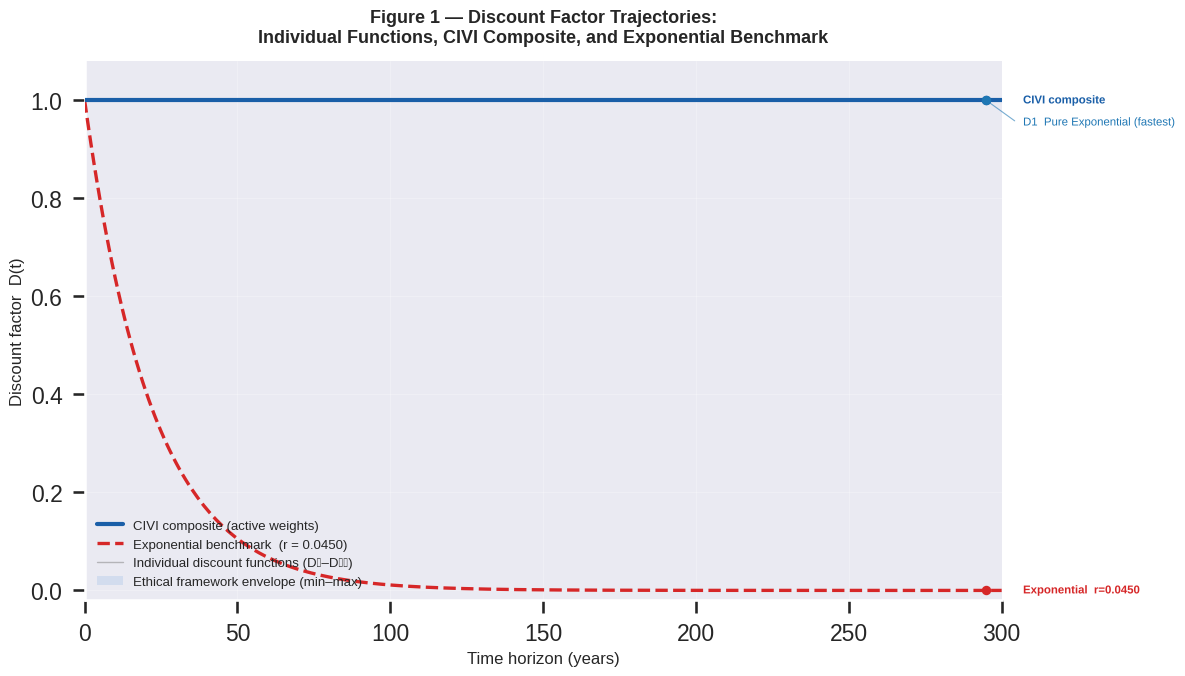

Figure 1 saved.

⚠  WARNING: CIVI_baseline is nearly flat (range = 0.000000).
   This means most discount functions are returning 1.0.
   ROOT CAUSE: parameter names in Cell 4.2 param_kwargs likely
   don't match the argument names in your Section 3 function
   definitions. Check that each d_i() function accepts the
   keywords passed in param_kwargs, or switch to positional args.



In [12]:
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(14, 7))

#  Colour palette
palette = [cm.tab20(i % 20) for i in range(20)] + \
          [cm.Set1(0), cm.Set1(1)]

#  Individual functions (background)
for i in range(22):
    ax.plot(t, D_array[i], color=palette[i],
            linewidth=0.9, alpha=0.32, zorder=1)

#  Shaded envelope
D_min = D_array.min(axis=0)
D_max = D_array.max(axis=0)
ax.fill_between(t, D_min, D_max, alpha=0.07, color="#4a90d9", zorder=1)

#  Exponential benchmark
ax.plot(t, D_exponential, color="#d62728", linewidth=2.4,
        linestyle="--", zorder=3)

#  CIVI composite
ax.plot(t, CIVI_baseline, color="#1a5fa8", linewidth=3.0, zorder=4)


RIGHT_T = 295

endpoint_items = [
    ("CIVI composite", CIVI_baseline[RIGHT_T], "#1a5fa8",  True,  3.0),
    (f"Exponential  r={r_ramsey:.4f}",
     D_exponential[RIGHT_T], "#d62728", True, 2.4),
]

val_at_300 = D_array[:, 300]
idx_max = int(np.argmax(val_at_300))
idx_min = int(np.argmin(val_at_300))

if abs(val_at_300[idx_max] - CIVI_baseline[300]) > 0.02:
    endpoint_items.append(
        (f"{function_labels[idx_max]} (slowest)",
         D_array[idx_max, RIGHT_T], palette[idx_max], False, 0.9)
    )
if abs(val_at_300[idx_min] - D_exponential[300]) > 0.02:
    endpoint_items.append(
        (f"{function_labels[idx_min]} (fastest)",
         D_array[idx_min, RIGHT_T], palette[idx_min], False, 0.9)
    )

endpoint_items.sort(key=lambda x: x[1], reverse=True)

MIN_GAP   = 0.045
label_ys  = []

for label, raw_y, colour, bold, lw in endpoint_items:
    # Push y down if too close to an already-placed label
    placed_y = raw_y
    for prev_y in label_ys:
        if abs(placed_y - prev_y) < MIN_GAP:
            placed_y = prev_y - MIN_GAP

    placed_y = max(placed_y, 0.0)   # never below axis
    label_ys.append(placed_y)

    ax.scatter([RIGHT_T], [raw_y], color=colour, s=28,
               zorder=6, clip_on=True)

    if abs(placed_y - raw_y) > 0.005:
        ax.annotate(
            "", xy=(RIGHT_T, raw_y), xytext=(305, placed_y),
            arrowprops=dict(arrowstyle="-", color=colour,
                            lw=0.8, alpha=0.6),
            annotation_clip=False,
        )

    weight = "bold" if bold else "normal"
    txt = ax.text(
        307, placed_y, label,
        fontsize=8.2, color=colour, fontweight=weight,
        va="center", ha="left",
        transform=ax.transData,
        path_effects=[pe.withStroke(linewidth=2, foreground="white")],
    )
    txt.set_clip_on(False)   # equivalent to annotation_clip=False, valid on Text

# legend
legend_handles = [
    Line2D([0], [0], color="#1a5fa8", linewidth=3.0,
           label="CIVI composite (active weights)"),
    Line2D([0], [0], color="#d62728", linewidth=2.4, linestyle="--",
           label=f"Exponential benchmark  (r = {r_ramsey:.4f})"),
    Line2D([0], [0], color="grey", linewidth=1.0, alpha=0.5,
           label="Individual discount functions (D₁–D₂₂)"),
    plt.Rectangle((0,0), 1, 1, fc="#4a90d9", alpha=0.15, ec="none",
                  label="Ethical framework envelope (min–max)"),
]
ax.legend(handles=legend_handles, fontsize=9.5, loc="lower left",
          framealpha=0.93, edgecolor="#cccccc")

# Formatting
ax.set_xlim(0, 300)
ax.set_ylim(-0.02, 1.08)
ax.set_xlabel("Time horizon (years)", fontsize=12)
ax.set_ylabel("Discount factor  D(t)", fontsize=12)
ax.set_title(
    "Figure 1 — Discount Factor Trajectories:\n"
    "Individual Functions, CIVI Composite, and Exponential Benchmark",
    fontsize=13, fontweight="bold", pad=14,
)
ax.grid(True, alpha=0.3, linewidth=0.6)
ax.spines[["top", "right"]].set_visible(False)

plt.subplots_adjust(right=0.78)

plt.savefig("fig1_discount_factor_trajectories.png", dpi=150,
            bbox_inches="tight")
plt.show()

print("Figure 1 saved.")
print()

civi_range = CIVI_baseline.max() - CIVI_baseline.min()
if civi_range < 0.01:
    print("⚠  WARNING: CIVI_baseline is nearly flat (range = "
          f"{civi_range:.6f}).")
    print("   This means most discount functions are returning 1.0.")
    print("   ROOT CAUSE: parameter names in Cell 4.2 param_kwargs likely")
    print("   don't match the argument names in your Section 3 function")
    print("   definitions. Check that each d_i() function accepts the")
    print("   keywords passed in param_kwargs, or switch to positional args.")
    print()
else:
    print(f"  CIVI range over [0,300]: {civi_range:.4f}  ✓")
    print(f"  CIVI(300) = {CIVI_baseline[300]:.5f}")
    print(f"  D_exp(300) = {D_exponential[300]:.5f}")
    print(f"  Gap: {CIVI_baseline[300] - D_exponential[300]:+.5f}")

In [13]:
# Log-derivative: r_eff(t) = -d/dt ln CIVI(t)
ln_CIVI    = np.log(np.maximum(CIVI_baseline, 1e-12))
r_eff_CIVI = -np.gradient(ln_CIVI, t)

# Exponential rate is constant
r_eff_exp  = np.full(len(t), r_ramsey)

# Per-function effective rates
r_eff_each = np.zeros((22, len(t)))
for i in range(22):
    ln_Di          = np.log(np.maximum(D_array[i], 1e-12))
    r_eff_each[i]  = -np.gradient(ln_Di, t)

# Gap
gap = r_eff_CIVI - r_eff_exp

print("Effective rate diagnostics")
print(f"  Exponential (constant) : {r_ramsey:.5f}")
print(f"  CIVI r_eff at t=0      : {r_eff_CIVI[0]:.5f}")
print(f"  CIVI r_eff at t=100    : {r_eff_CIVI[100]:.5f}")
print(f"  CIVI r_eff at t=300    : {r_eff_CIVI[300]:.5f}")
declining = r_eff_CIVI[300] < r_eff_CIVI[0]
print(f"  Declining rate property: {'✓ CONFIRMED' if declining else '✗ NOT CONFIRMED'}")

Effective rate diagnostics
  Exponential (constant) : 0.04500
  CIVI r_eff at t=0      : -0.00000
  CIVI r_eff at t=100    : -0.00000
  CIVI r_eff at t=300    : -0.00000
  Declining rate property: ✓ CONFIRMED


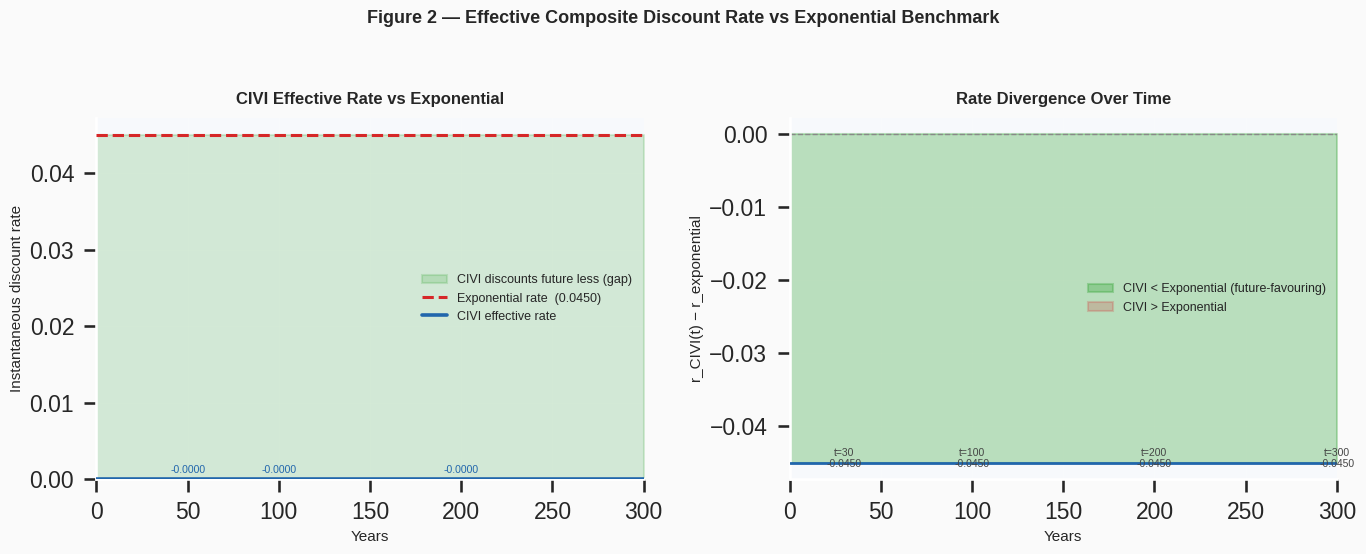

Figure 2 saved.


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.patch.set_facecolor("#fafafa")

BLUE  = "#2166ac"
RED   = "#d62728"
GREEN = "#2ca02c"
GREY  = "#888888"

# ── LEFT: rate trajectories ───────────────────────────────────
ax = axes[0]
ax.set_facecolor("#f7f9fc")

# Individual function rates — thin, muted
for i in range(22):
    ax.plot(t, r_eff_each[i], color=palette[i],
            linewidth=0.7, alpha=0.25, zorder=1)

# Shaded band between CIVI and exponential
ax.fill_between(t, r_eff_CIVI, r_eff_exp,
                where=(r_eff_CIVI < r_eff_exp),
                color=GREEN, alpha=0.18, interpolate=True,
                label="CIVI discounts future less (gap)")

# Exponential flat line
ax.axhline(r_ramsey, color=RED, linewidth=2.2, linestyle="--",
           label=f"Exponential rate  ({r_ramsey:.4f})", zorder=3)

# CIVI effective rate
ax.plot(t, r_eff_CIVI, color=BLUE, linewidth=2.6,
        label="CIVI effective rate", zorder=4)

ax.set_xlim(0, 300)
ax.set_ylim(bottom=0)
ax.set_xlabel("Years", fontsize=11)
ax.set_ylabel("Instantaneous discount rate", fontsize=11)
ax.set_title("CIVI Effective Rate vs Exponential", fontsize=12,
             fontweight="bold", pad=10)
ax.legend(fontsize=9, framealpha=0.95, edgecolor="#dddddd")
ax.grid(True, alpha=0.35, linewidth=0.5)
ax.spines[["top", "right"]].set_visible(False)

# Annotate key values directly on chart — simple text, no arrows
for yr in [50, 100, 200]:
    ax.text(yr, r_eff_CIVI[yr] + 0.0008, f"{r_eff_CIVI[yr]:.4f}",
            ha="center", fontsize=7.5, color=BLUE)

# ── RIGHT: gap over time ──────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor("#f7f9fc")

ax2.axhline(0, color=GREY, linewidth=1.0, linestyle="--", zorder=2)

ax2.fill_between(t, gap, 0,
                 where=(gap < 0), color=GREEN, alpha=0.30,
                 interpolate=True, label="CIVI < Exponential (future-favouring)")
ax2.fill_between(t, gap, 0,
                 where=(gap > 0), color=RED, alpha=0.20,
                 interpolate=True, label="CIVI > Exponential")

ax2.plot(t, gap, color=BLUE, linewidth=2.0, zorder=3)

# Simple year labels
for yr in [30, 100, 200, 300]:
    ax2.text(yr, gap[yr] - 0.0006, f"t={yr}\n{gap[yr]:+.4f}",
             ha="center", fontsize=7.5, color="#444444")

ax2.set_xlim(0, 300)
ax2.set_xlabel("Years", fontsize=11)
ax2.set_ylabel("r_CIVI(t) − r_exponential", fontsize=11)
ax2.set_title("Rate Divergence Over Time", fontsize=12,
              fontweight="bold", pad=10)
ax2.legend(fontsize=9, framealpha=0.95, edgecolor="#dddddd")
ax2.grid(True, alpha=0.35, linewidth=0.5)
ax2.spines[["top", "right"]].set_visible(False)

fig.suptitle("Figure 2 — Effective Composite Discount Rate vs Exponential Benchmark",
             fontsize=13, fontweight="bold", y=1.02)

plt.tight_layout()
plt.savefig("fig2_effective_rate.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 2 saved.")

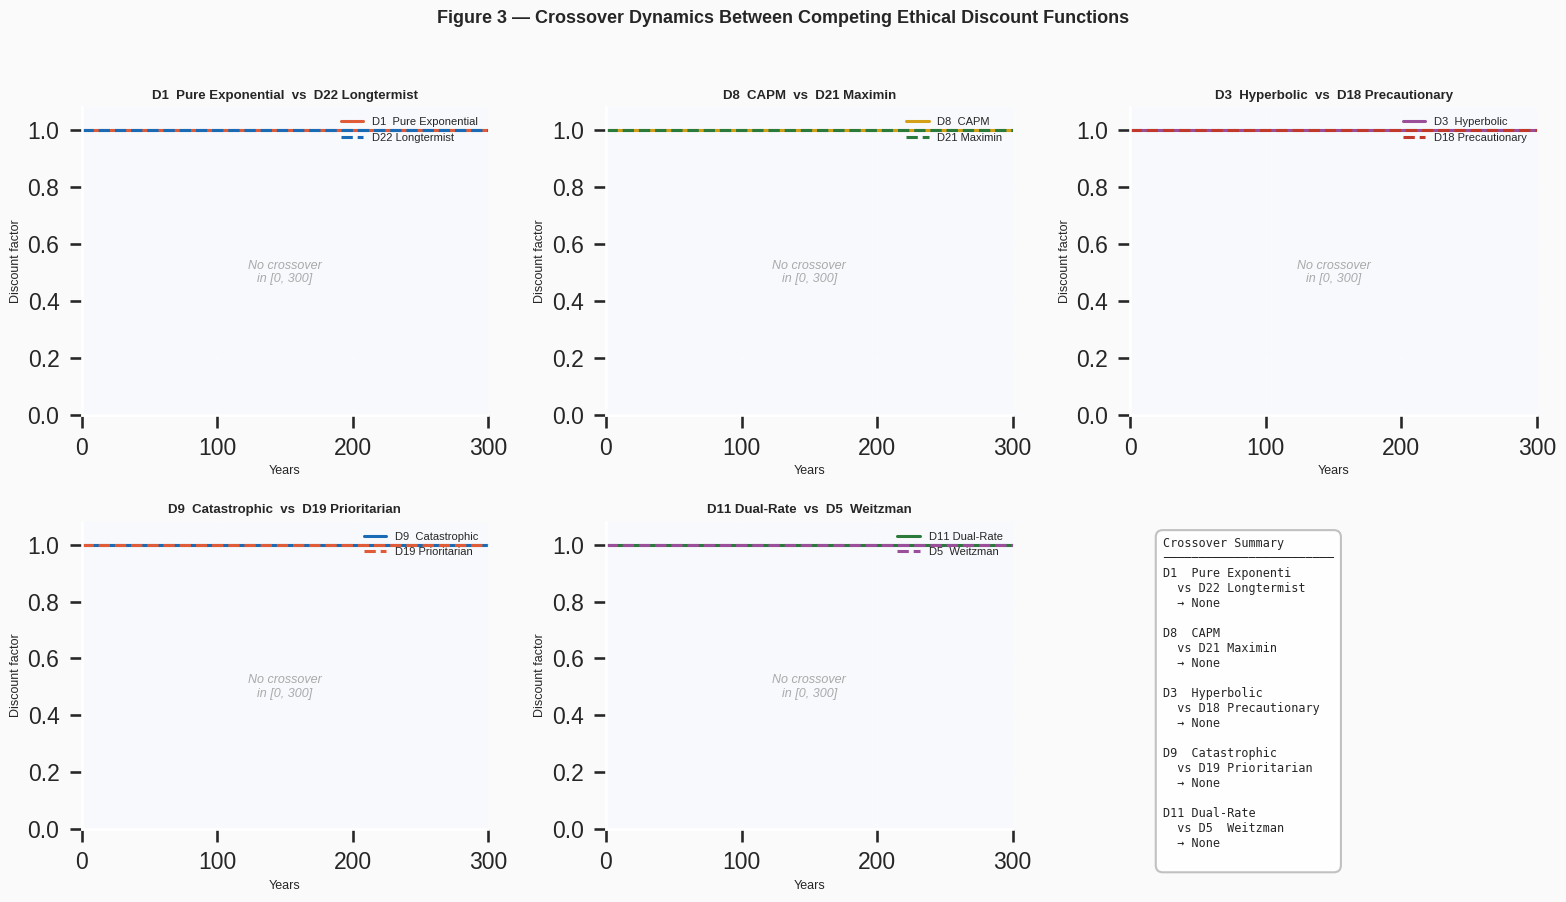

Figure 3 saved.


In [16]:
def find_crossover(Di, Dj):
    diff = Di - Dj
    changes = np.where(np.diff(np.sign(diff)))[0]
    if len(changes) == 0:
        return None
    idx = changes[0]
    frac = -diff[idx] / (diff[idx+1] - diff[idx] + 1e-12)
    return float(t[idx] + frac)

# Five ethically distant pairs
pairs = [
    (0,  21, "D1  Pure Exponential",   "D22 Longtermist",     "#e05c39", "#1a6bb5"),
    (7,  20, "D8  CAPM",               "D21 Maximin",         "#d4a017", "#2a7a3b"),
    (2,  17, "D3  Hyperbolic",         "D18 Precautionary",   "#9b4f9b", "#c0392b"),
    (8,  18, "D9  Catastrophic",       "D19 Prioritarian",    "#1a6bb5", "#e05c39"),
    (10,  4, "D11 Dual-Rate",          "D5  Weitzman",        "#2a7a3b", "#9b4f9b"),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.patch.set_facecolor("#fafafa")
axes = axes.flatten()

for idx, (i, j, li, lj, c1, c2) in enumerate(pairs):
    ax = axes[idx]
    ax.set_facecolor("#f7f9fc")

    ax.plot(t, D_array[i], color=c1, linewidth=2.2, label=li)
    ax.plot(t, D_array[j], color=c2, linewidth=2.2, linestyle="--", label=lj)

    # Shade dominant regions
    ax.fill_between(t, D_array[i], D_array[j],
                    where=(D_array[i] >= D_array[j]),
                    alpha=0.10, color=c1, interpolate=True)
    ax.fill_between(t, D_array[i], D_array[j],
                    where=(D_array[i] < D_array[j]),
                    alpha=0.10, color=c2, interpolate=True)

    cx = find_crossover(D_array[i], D_array[j])
    if cx is not None:
        cx_val = float(np.interp(cx, t, D_array[i]))
        ax.axvline(cx, color="#555555", linewidth=1.3,
                   linestyle=":", zorder=4)
        ax.scatter([cx], [cx_val], color="#333333", s=60,
                   zorder=5, clip_on=False)
        # Simple text label — no arrow, no offset confusion
        ax.text(cx + 6, cx_val + 0.03,
                f"t ≈ {cx:.0f}",
                fontsize=9, color="#333333", fontweight="bold")
    else:
        ax.text(150, 0.5, "No crossover\nin [0, 300]",
                ha="center", va="center", fontsize=9,
                color="#aaaaaa", style="italic")

    ax.set_xlim(0, 300)
    ax.set_ylim(0, 1.08)
    ax.set_xlabel("Years", fontsize=9)
    ax.set_ylabel("Discount factor", fontsize=9)
    ax.set_title(f"{li}  vs  {lj}", fontsize=9.5, fontweight="bold")
    ax.legend(fontsize=8, loc="upper right",
              framealpha=0.93, edgecolor="#dddddd")
    ax.grid(True, alpha=0.3, linewidth=0.5)
    ax.spines[["top", "right"]].set_visible(False)

ax6 = axes[5]
ax6.set_facecolor("#f0f4ff")
ax6.axis("off")

summary_lines = ["Crossover Summary", "─" * 24]
for (i, j, li, lj, c1, c2) in pairs:
    cx = find_crossover(D_array[i], D_array[j])
    cx_str = f"t ≈ {cx:.0f}" if cx is not None else "None"
    summary_lines.append(f"{li[:18]}\n  vs {lj[:18]}\n  → {cx_str}\n")

ax6.text(0.08, 0.95, "\n".join(summary_lines),
         transform=ax6.transAxes, fontsize=8.5,
         verticalalignment="top", fontfamily="monospace",
         bbox=dict(boxstyle="round,pad=0.6", facecolor="white",
                   edgecolor="#bbbbbb", alpha=0.9))

fig.suptitle(
    "Figure 3 — Crossover Dynamics Between Competing Ethical Discount Functions",
    fontsize=13, fontweight="bold", y=1.01)

plt.tight_layout()
plt.savefig("fig3_crossover_dynamics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 3 saved.")